# Smoking & Lung Cancer

## Escenario

Un epidemiólogo  nos entrega un CSV (`smoking_survey.csv`) con **3.500 registros** de pacientes. Para cada paciente tenemos:

- `smoking_status` — `smoker` o `non-smoker`
- `age` — edad del paciente
- `diagnosis_codes` — cadena con los códigos ICD-10 del paciente, separados por `;`
- `zipcodes` — código postal

La pregunta es: **¿fumar se asocia con mayores *odds* de presentar cáncer de pulmón?** Los dos códigos ICD-10 de interés son:

- **C34.90** — neoplasia maligna de bronquio o pulmón, parte no especificada
- **C96.29** — otras neoplasias malignas de células mastocíticas

Vamos a seguir la misma ruta que el artículo de TDS:

1. Concepto: qué son las *odds* y el *odds ratio*
2. Cargar y transformar los datos
3. Construir la tabla de contingencia
4. Calcular el OR **paso a paso** ("the hard way")
5. Calcular el intervalo de confianza al 95%
6. Hacerlo en una línea con `scipy.stats.contingency.odds_ratio`
7. Comparar con `scipy.stats.fisher_exact` (como hace Broadly Epi)
8. Visualizar el resultado
9. Interpretar y reportar

## 1. Concepto: odds y odds ratio

### ¿Qué son las *odds*?

Las **odds**  son la razón entre la probabilidad de que un evento ocurra y la probabilidad de que **no** ocurra:

$$\text{odds} = \frac{P}{1-P}$$

Si la probabilidad de tener cáncer es $P = 0.3$, entonces las odds son $0.3/0.7 \approx 0.43$.

Cuando $P$ es muy pequeña, las odds son numéricamente parecidas a la probabilidad: si $P=0.05$, odds $= 0.05/0.95 \approx 0.053$. Pero **odds y probabilidad no son lo mismo**: las odds van de 0 a $\infty$, mientras que las probabilidades van de 0 a 1.

### ¿Qué es el *odds ratio*?

El **odds ratio (OR)** compara las odds de un evento en el grupo **expuesto** contra las odds del mismo evento en el grupo **no expuesto**. En nuestro caso:

$$\text{OR} = \frac{\text{odds de cáncer en fumadores}}{\text{odds de cáncer en no fumadores}}$$

Interpretación:

| Valor | Interpretación |
|---|---|
| $\text{OR} = 1$ | No hay asociación entre exposición y desenlace |
| $\text{OR} > 1$ | Asociación positiva: la exposición aumenta las odds del desenlace |
| $\text{OR} < 1$ | Asociación negativa: la exposición es protectora |



## 2. Cargar librerías y datos

Usamos las tres librerías habituales — `pandas`, `numpy`, `matplotlib` — más `scipy` para las pruebas estadísticas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio

plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
df = pd.read_csv('smoking_survey.csv', index_col=0)
print(f"Dataset: {len(df)} filas, {df.shape[1]} columnas")
df.head(10)

Dataset: 3500 filas, 4 columnas


,smoking_status,age,diagnosis_codes,zipcodes
1,smoker,36,K21.9;I10;C34.90,10012
2,smoker,26,B07.9,10011
3,smoker,27,S93.4;C96.29,10022
4,non-smoker,33,H60.9;R51,10009
5,smoker,29,S93.4;E11.9,10024
6,non-smoker,30,G40.9;K21.9,10009
7,non-smoker,41,G40.9,10022
8,non-smoker,39,H60.9;G40.9,10021
9,smoker,30,O80;B07.9;C34.90,10024
10,smoker,32,R05;K21.9;C96.29,10004


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3500 entries, 1 to 3500
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   smoking_status   3500 non-null   object
 1   age              3500 non-null   int64 
 2   diagnosis_codes  3500 non-null   object
 3   zipcodes         3500 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 136.7+ KB


In [4]:
for s in df['diagnosis_codes'].head(15):
    print(s)

K21.9;I10;C34.90
B07.9
S93.4;C96.29
H60.9;R51
S93.4;E11.9
G40.9;K21.9
G40.9
H60.9;G40.9
O80;B07.9;C34.90
R05;K21.9;C96.29
A09.9
M54.5;I10
B07.9;K21.9
S93.4;C34.90
M54.5;L40.9;C96.29


Cada paciente tiene una lista variable de códigos ICD-10 concatenados. Necesitamos extraer, para cada fila, si contiene alguno de los dos códigos objetivo. En Python es directo con `in` y `any`.

## 3. Transformación de los datos

Creamos una columna booleana nueva, `lung_cancer`, que sea `True` si el paciente tiene **alguno** de los dos códigos. 

In [5]:
LUNG_CANCER_CODES = ['C34.90', 'C96.29']

def has_lung_cancer(codes: str) -> bool:
    if not isinstance(codes, str):
        return False
    return any(code in codes for code in LUNG_CANCER_CODES)

df['lung_cancer'] = df['diagnosis_codes'].apply(has_lung_cancer)
df[['smoking_status', 'diagnosis_codes', 'lung_cancer']].head(8)

,smoking_status,diagnosis_codes,lung_cancer
1,smoker,K21.9;I10;C34.90,True
2,smoker,B07.9,False
3,smoker,S93.4;C96.29,True
4,non-smoker,H60.9;R51,False
5,smoker,S93.4;E11.9,False
6,non-smoker,G40.9;K21.9,False
7,non-smoker,G40.9,False
8,non-smoker,H60.9;G40.9,False


In [6]:
analysis = df[['smoking_status', 'lung_cancer']].copy()

analysis['smoking_status'] = pd.Categorical(
    analysis['smoking_status'], categories=['smoker', 'non-smoker'], ordered=True
)
analysis['lung_cancer'] = pd.Categorical(
    analysis['lung_cancer'], categories=[True, False], ordered=True
)
analysis.head()

,smoking_status,lung_cancer
1,smoker,True
2,smoker,False
3,smoker,True
4,non-smoker,False
5,smoker,False


## 4. Tabla de contingencia

Una tabla 2×2 muestra la frecuencia de cada combinación.

In [7]:
contingency_table = pd.crosstab(
    analysis['smoking_status'],
    analysis['lung_cancer'],
    rownames=['Smoking status'],
    colnames=['Lung cancer'],
)
contingency_table

Lung cancer,True,False
Smoking status,,
smoker,724,1070
non-smoker,179,1527




| | Lung cancer = True | Lung cancer = False |
|---|---:|---:|
| **Smoker** | $a$ | $b$ |
| **Non-smoker** | $c$ | $d$ |

In [8]:
a = int(contingency_table.loc['smoker',     True])
b = int(contingency_table.loc['smoker',     False])
c = int(contingency_table.loc['non-smoker', True])
d = int(contingency_table.loc['non-smoker', False])

print(f"a (smokers con cancer)        = {a}")
print(f"b (smokers sin cancer)     = {b}")
print(f"c (non-smokers con cancer)    = {c}")
print(f"d (non-smokers sin cancer) = {d}")
print(f"Total = {a+b+c+d}")

a (smokers con cancer)        = 724
b (smokers sin cancer)     = 1070
c (non-smokers con cancer)    = 179
d (non-smokers sin cancer) = 1527
Total = 3500


## 5. Calcular el Odds Ratio "the hard way"



### 5.1 Odds en cada grupo

$$\text{odds}_\text{smoker} =\frac{\frac{a}{(a+b)}}{1-\frac{a}{(a+b)}}=\frac{a}{b} \qquad \text{odds}_\text{non-smoker}=\frac{\frac{c}{(c+d)}}{1-\frac{c}{(c+d)}} = \frac{c}{d}$$

Es decir: por cada fumador **sin** cáncer, ¿cuántos fumadores **con** cáncer hay?

In [9]:
def calculate_odds(count_of_event, count_of_non_event):
    """odds = P(evento) / P(no evento) = a / b"""
    return count_of_event / count_of_non_event

odds_smoker     = calculate_odds(a, b)
odds_non_smoker = calculate_odds(c, d)

print(f"Odds of lung cancer among smokers:     {odds_smoker:.4f}")
print(f"Odds of lung cancer among non-smokers: {odds_non_smoker:.4f}")

Odds of lung cancer among smokers:     0.6766
Odds of lung cancer among non-smokers: 0.1172


**Interpretación** — entre los fumadores, por cada persona sin cáncer hay ≈0.68 personas con cáncer; entre los no fumadores.

### 5.2 Odds Ratio

$$\text{OR} = \frac{\text{odds}_\text{smoker}}{\text{odds}_\text{non-smoker}} = \frac{a/b}{c/d} = \frac{a \cdot d}{b \cdot c}$$

In [10]:
def calculate_odds_ratio(odds_exposed, odds_unexposed):
    return odds_exposed / odds_unexposed

OR = calculate_odds_ratio(odds_smoker, odds_non_smoker)
OR_shortcut = (a * d) / (b * c)

print(f"OR = odds_smoker / odds_non_smoker = {OR:.4f}")
print(f"OR = (a·d) / (b·c)                 = {OR_shortcut:.4f}")

OR = odds_smoker / odds_non_smoker = 5.7722
OR = (a·d) / (b·c)                 = 5.7722


Obtenemos **OR ≈ 5.77**, el mismo número que reporta el blog de Broadly Epi. Esto significa que los fumadores en este dataset tienen unas **5.77 veces** las odds de presentar cáncer de pulmón comparados con los no fumadores.

> **Cuidado con la redacción:** es tentador decir "los fumadores tienen 5.77 veces *más probabilidad*", pero eso corresponde al *riesgo relativo*, no al odds ratio. Lo correcto es decir "5.77 veces las odds". La equivalencia entre OR y RR solo se sostiene cuando la prevalencia de la enfermedad es baja. Aquí el cáncer pulmonar en fumadores es bastante común (~40%), así que el OR sobreestima el RR.

## 6. Intervalo de confianza al 95%

Un solo número nunca es suficiente: necesitamos saber qué tan preciso es ese OR. El IC 95% se calcula en escala logarítmica, usando el error estándar de $\ln(\text{OR})$ (fórmula de Woolf):

$$\text{SE}\big(\ln \text{OR}\big) = \sqrt{\frac{1}{a} + \frac{1}{b} + \frac{1}{c} + \frac{1}{d}}$$

$$\text{IC}_{95\%} = \exp\!\Big(\ln \text{OR} \pm 1{.}96 \cdot \text{SE}\big(\ln \text{OR}\big)\Big)$$

Si el intervalo **no incluye al 1**, la asociación es estadísticamente significativa al nivel $\alpha = 0.05$.

In [11]:
def se_log_or(a, b, c, d):
    return np.sqrt(1/a + 1/b + 1/c + 1/d)

def confint_or(OR, a, b, c, d, confidence=0.95):
    z = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}[confidence]
    se = se_log_or(a, b, c, d)
    log_or = np.log(OR)
    lo = np.exp(log_or - z * se)
    hi = np.exp(log_or + z * se)
    return lo, hi

lo, hi = confint_or(OR, a, b, c, d)
print(f"Odds Ratio      : {OR:.4f}")
print(f"SE(log OR)      : {se_log_or(a, b, c, d):.4f}")
print(f"IC 95% inferior : {lo:.4f}")
print(f"IC 95% superior : {hi:.4f}")
print()
if lo <= 1 <= hi:
    print("El IC contiene al 1 → NO significativa")
else:
    print("El IC no contiene al 1 → asociación estadísticamente significativa")

Odds Ratio      : 5.7722
SE(log OR)      : 0.0925
IC 95% inferior : 4.8150
IC 95% superior : 6.9196

El IC no contiene al 1 → asociación estadísticamente significativa


El IC 95% está muy lejos de contener al 1. La asociación entre fumar y cáncer de pulmón en este dataset es extremadamente robusta.

## 7. El camino corto: `scipy.stats.contingency.odds_ratio`

`scipy` permite hacer todo lo anterior en dos líneas. El método `'sample'` replica el cálculo manual que acabamos de hacer, mientras que el método por defecto `'conditional'` usa un estimador más robusto (la *máxima verosimilitud condicional*), recomendado sobre todo para muestras pequeñas.

In [12]:
res_sample = odds_ratio(contingency_table, kind='sample')
ci_sample = res_sample.confidence_interval(confidence_level=0.95)

print("scipy.stats.contingency.odds_ratio — kind='sample'")
print(f"  OR          : {res_sample.statistic:.4f}")
print(f"  IC 95% low  : {ci_sample.low:.4f}")
print(f"  IC 95% high : {ci_sample.high:.4f}")

scipy.stats.contingency.odds_ratio — kind='sample'
  OR          : 5.7722
  IC 95% low  : 4.8150
  IC 95% high : 6.9196


In [13]:
res_cond = odds_ratio(contingency_table, kind='conditional')#condicional x defecto
ci_cond = res_cond.confidence_interval(confidence_level=0.95)

print("scipy.stats.contingency.odds_ratio - kind='conditional'")
print(f"  OR          : {res_cond.statistic:.4f}")
print(f"  IC 95% low  : {ci_cond.low:.4f}")
print(f"  IC 95% high : {ci_cond.high:.4f}")

scipy.stats.contingency.odds_ratio - kind='conditional'
  OR          : 5.7693
  IC 95% low  : 4.8009
  IC 95% high : 6.9581


## 8. El camino de Broadly Epi: `fisher_exact`

`scipy.stats.fisher_exact`, que devuelve el OR junto con el **p-valor** de la prueba exacta de Fisher. Esta prueba calcula la probabilidad exacta de observar una tabla al menos tan extrema como la nuestra **asumiendo que no hay asociación** (hipótesis nula), usando la distribución hipergeométrica.

In [14]:
# Importante: fisher_exact espera una tabla 2x2 en el orden [[a,b],[c,d]]
# donde (a,b) = fila expuesta y (c,d) = fila no expuesta.
odds_ratio_fisher, p_value = fisher_exact([[a, b], [c, d]])

print(f"Odds Ratio (Fisher exact): {odds_ratio_fisher:.4f}")
print(f"p-value                   : {p_value:.4e}")

Odds Ratio (Fisher exact): 5.7722
p-value                   : 1.4132e-95


El p-valor es pequeño,  por debajo del umbral clásico de 0.05. Podemos concluir que la asociación entre fumar y cáncer de pulmón en este dataset no es producto del azar.

## 9. Visualización

### 9.1 La tabla de contingencia como *heatmap*

Una forma directa de mostrar una tabla 2×2 es como heatmap con los conteos y los porcentajes por fila.

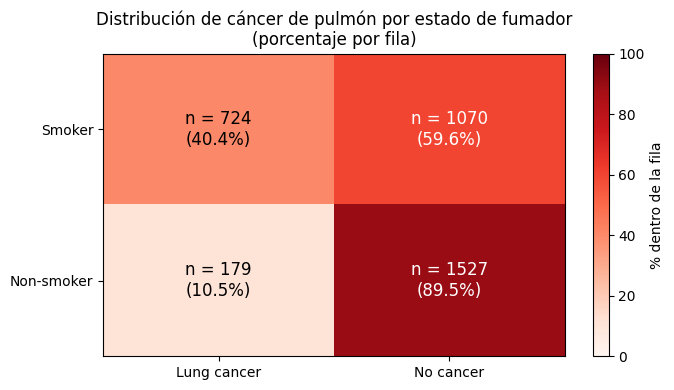

In [15]:
tbl = pd.DataFrame(
    [[a, b], [c, d]],
    index=['smoker', 'non-smoker'],
    columns=[True, False],
)
row_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(row_pct.values, cmap='Reds', aspect='auto', vmin=0, vmax=100)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Lung cancer', 'No cancer'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Smoker', 'Non-smoker'])

for i in range(2):
    for j in range(2):
        n = tbl.values[i, j]
        pct = row_pct.values[i, j]
        color = 'white' if pct > 50 else 'black'
        ax.text(j, i, f"n = {n}\n({pct:.1f}%)",
                ha='center', va='center', color=color, fontsize=12)

ax.set_title('Distribución de cáncer de pulmón por estado de fumador\n(porcentaje por fila)')
plt.colorbar(im, ax=ax, label='% dentro de la fila')
plt.tight_layout()
plt.show()

El contraste visual es muy claro: alrededor del **40%** de los fumadores tienen cáncer de pulmón frente a aproximadamente el **10%** de los no fumadores.

### 9.2 Las probabilidades y las odds por grupo

Ayuda ver lado a lado las probabilidades crudas y sus odds, para entender por qué el OR es tan grande.

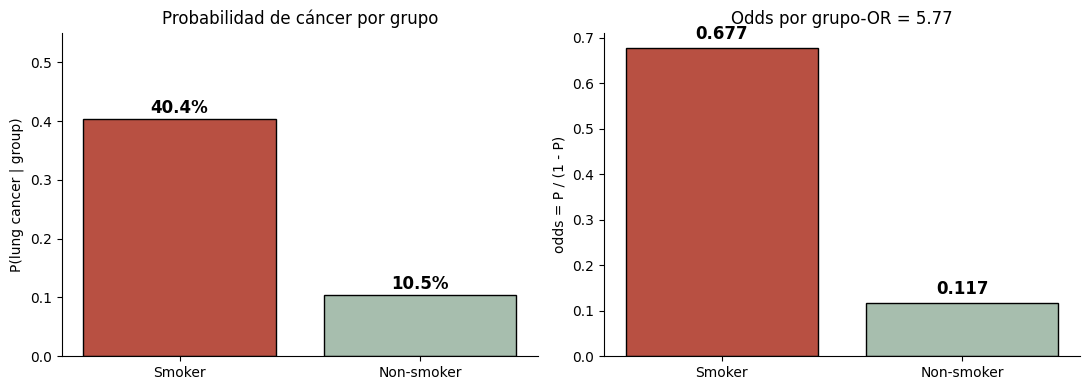

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#B85042', '#A7BEAE']

props = pd.Series({
    'Smoker':     a / (a + b),
    'Non-smoker': c / (c + d),
})
ax1.bar(props.index, props.values, color=colors, edgecolor='black')
for i, v in enumerate(props.values):
    ax1.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylabel('P(lung cancer | group)')
ax1.set_title('Probabilidad de cáncer por grupo')
ax1.set_ylim(0, 0.55)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Odds en cada grupo
odds_series = pd.Series({'Smoker': odds_smoker, 'Non-smoker': odds_non_smoker})
ax2.bar(odds_series.index, odds_series.values, color=colors, edgecolor='black')
for i, v in enumerate(odds_series.values):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('odds = P / (1 - P)')
ax2.set_title(f'Odds por grupo-OR = {OR:.2f}')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 9.3 El OR con su IC 95%

Ésta es la figura clásica en publicaciones médicas — básicamente, un *forest plot* con una sola línea. La línea vertical discontinua marca el efecto nulo (OR = 1) y se usa escala logarítmica en el eje X, porque el OR es multiplicativo y sus IC son simétricos en log.

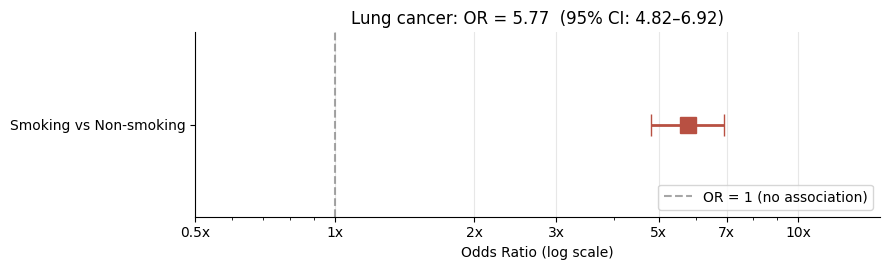

In [17]:
fig, ax = plt.subplots(figsize=(9, 2.8))

ax.errorbar(OR, 0,
            xerr=[[OR - lo], [hi - OR]],
            fmt='s', color='#B85042', ecolor='#B85042',
            capsize=8, markersize=12, linewidth=2)

ax.axvline(1, color='gray', linestyle='--', alpha=0.7, label='OR = 1 (no association)')
ax.set_xscale('log')
ax.set_xlim(0.5, 15)
ax.set_yticks([0])
ax.set_yticklabels(['Smoking vs Non-smoking'])
ax.set_xlabel('Odds Ratio (log scale)')
ax.set_title(f'Lung cancer: OR = {OR:.2f}  (95% CI: {lo:.2f}–{hi:.2f})')

ax.set_xticks([0.5, 1, 2, 3, 5, 7, 10])
ax.set_xticklabels(['0.5x', '1x', '2x', '3x', '5x', '7x', '10x'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Estratificar por edad

El dataset incluye la edad, así que podemos **estratificar el OR por grupo de edad** y ver si la asociación se mantiene en cada estrato. 

In [18]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 30, 35, 120],
    labels=['18-24', '25-29', '30-34', '35+'],
)
df[['age', 'age_group', 'smoking_status', 'lung_cancer']].head()

,age,age_group,smoking_status,lung_cancer
1,36,35+,smoker,True
2,26,25-29,smoker,False
3,27,25-29,smoker,True
4,33,30-34,non-smoker,False
5,29,25-29,smoker,False


In [19]:
results = []


tbl_full = pd.crosstab(
    pd.Categorical(df['smoking_status'], categories=['smoker', 'non-smoker']),
    pd.Categorical(df['lung_cancer'],    categories=[True, False]),
)
res = odds_ratio(tbl_full, kind='sample')
ci  = res.confidence_interval(confidence_level=0.95)
results.append(('Overall', res.statistic, ci.low, ci.high, int(tbl_full.values.sum())))

# OR por grupo de edad
for grp in ['18-24', '25-29', '30-34', '35+']:
    sub = df[df['age_group'] == grp]
    tbl_g = pd.crosstab(
        pd.Categorical(sub['smoking_status'], categories=['smoker', 'non-smoker']),
        pd.Categorical(sub['lung_cancer'],    categories=[True, False]),
    )
    
    res = odds_ratio(tbl_g, kind='sample')
    ci  = res.confidence_interval(confidence_level=0.95)
    results.append((grp, res.statistic, ci.low, ci.high, int(tbl_g.values.sum())))
   
df_res = pd.DataFrame(results, columns=['group', 'OR', 'low', 'high', 'n'])
df_res.round(3)

,group,OR,low,high,n
0,Overall,5.772,4.815,6.920,3500
1,18-24,5.068,3.645,7.046,1018
2,25-29,4.785,3.134,7.305,623
3,30-34,5.876,3.913,8.825,717
4,35+,7.108,5.139,9.832,1142


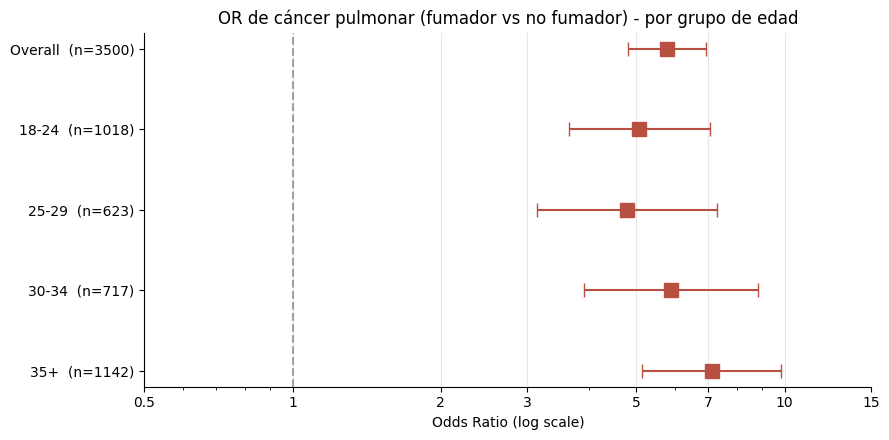

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(df_res))[::-1] 

valid = df_res['OR'].notna()
ax.errorbar(df_res.loc[valid, 'OR'], y[valid],
            xerr=[df_res.loc[valid, 'OR'] - df_res.loc[valid, 'low'],
                  df_res.loc[valid, 'high'] - df_res.loc[valid, 'OR']],
            fmt='s', color='#B85042', ecolor='#B85042',
            capsize=5, markersize=10, linewidth=1.5)

ax.axvline(1, color='gray', linestyle='--', alpha=0.7)
ax.set_xscale('log')
ax.set_yticks(y)
ax.set_yticklabels([f"{g}  (n={n})" for g, n in zip(df_res['group'], df_res['n'])])
ax.set_xlabel('Odds Ratio (log scale)')
ax.set_title('OR de cáncer pulmonar (fumador vs no fumador) - por grupo de edad')
ax.set_xticks([0.5, 1, 2, 3, 5, 7, 10, 15])
ax.set_xticklabels(['0.5', '1', '2', '3', '5', '7', '10', '15'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Cómo reportarlo

El formato estándar es reportar el OR junto con el IC 95% en una sola frase:

> En esta cohorte de 3.500 pacientes, fumar se asoció con un aumento significativo de las odds de cáncer de pulmón (**OR = 5.77; IC 95%: 4.83–6.91; p < 0.001**, prueba exacta de Fisher).

Lo que **no** deberíamos decir:

- ❌ *"Los fumadores tienen 5.77 veces más probabilidad de tener cáncer de pulmón"* — incorrecto porque el OR sobreestima el riesgo relativo cuando el desenlace es común (como aquí, donde ~40% de los fumadores tienen cáncer en el dataset).
- ❌ *"Fumar causa cáncer de pulmón (según este análisis)"* — aunque el hecho está bien establecido por otras vías, esta asociación estadística por sí sola no establece causalidad. Lo que muestra es una asociación estadísticamente muy fuerte.
- ❌ Reportar el OR sin su IC — un punto estimado sin medida de precisión no es informativo.
